In [7]:
import glob

files = glob.glob("youtube-dataset/*.csv")
print(files)

['youtube-dataset/Youtube04.csv', 'youtube-dataset/Youtube02.csv', 'youtube-dataset/Youtube05.csv', 'youtube-dataset/Youtube01.csv', 'youtube-dataset/Youtube03.csv']


In [8]:
import pandas as pd

df = []

for i in files:
    df.append(pd.read_csv(i))

In [17]:
df = pd.concat(df, ignore_index= True)

In [18]:
df.head()

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
0,z12rwfnyyrbsefonb232i5ehdxzkjzjs2,Lisa Wellas,NaN,+447935454150 lovely girl talk to me xxx﻿,1
1,z130wpnwwnyuetxcn23xf5k5ynmkdpjrj04,jason graham,2015-05-29T02:26:10.652000,I always end up coming back to this song<br />﻿,0
2,z13vsfqirtavjvu0t22ezrgzyorwxhpf3,Ajkal Khan,NaN,"my sister just received over 6,500 new <a rel=...",1
3,z12wjzc4eprnvja4304cgbbizuved35wxcs,Dakota Taylor,2015-05-29T02:13:07.810000,Cool﻿,0
4,z13xjfr42z3uxdz2223gx5rrzs3dt5hna,Jihad Naser,NaN,Hello I&#39;am from Palastine﻿,1


In [19]:
df.shape

(1955, 5)

In [20]:
df.columns

Index(['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS'], dtype='str')

we're trying to check wether it's spam or not
what will help us is column content and class others aren't important -> drop

In [28]:
df.drop(['COMMENT_ID','DATE','AUTHOR'], axis=1, inplace= True)

In [29]:
df.describe()

,CLASS
count,1955.000000
mean,0.513555
std,0.499944
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1955 entries, 0 to 1954
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   CONTENT  1955 non-null   str  
 1   CLASS    1955 non-null   int64
dtypes: int64(1), str(1)
memory usage: 30.7 KB


In [31]:
df.isnull().sum()

CONTENT    0
CLASS      0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(196)

In [33]:
df.drop_duplicates(inplace=True)

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df['CLASS'].value_counts()

CLASS
0    919
1    840
Name: count, dtype: int64

<Axes: xlabel='CLASS', ylabel='count'>

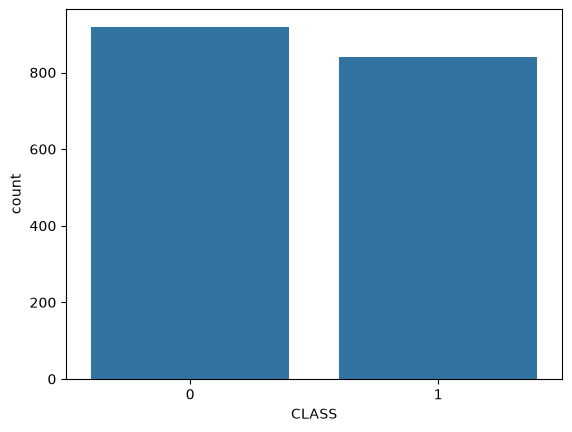

In [36]:
from matplotlib import pyplot as plt
import seaborn as sns
counts = df['CLASS'].value_counts()
sns.countplot(x="CLASS", data=df)

In [37]:
x = df["CONTENT"]
y = df["CLASS"]

In [38]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: CLASS, dtype: int64

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [43]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1407,), (352,), (1407,), (352,))

In [50]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer() # instance

In [52]:
x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.transform(x_test)

In [51]:
print(type(vectorizer))

<class 'sklearn.feature_extraction.text.CountVectorizer'>


In [54]:
x_test.shape

(352, 3845)

In [55]:
from sklearn.naive_bayes import MultinomialNB
NB = MultinomialNB()

In [56]:
NB.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[752.,655.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.63,-0.76]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 3845)","[[ 2.,30., 1.,..., 0., 0., 0.], [ 4.,24., 0.,..., 1., 1., 1.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 3845)","[[-8.14,-5.8 ,-8.54,...,-9.24,-9.24,-9.24], [-8.26,-6.65,-9.87,...,-9.18,-9.18,-9.18]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3845


In [57]:
NB.get_params()

{'alpha': 1.0, 'class_prior': None, 'fit_prior': True, 'force_alpha': True}

In [59]:
import numpy as np
np.exp(NB.class_log_prior_)

array([0.5344705, 0.4655295])

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay, recall_score, precision_score
y_pred = NB.predict(x_test)

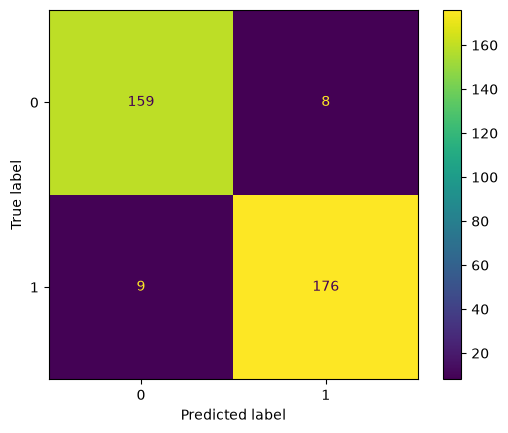

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [64]:
new_sample = ["This is a great video", "I learned alot", "I hate this content", "It's terrible", "Click this link to get 100$"]
new_sample_transformed = vectorizer.transform(new_sample)
predictions = NB.predict(new_sample_transformed)

In [65]:
predictions

array([0, 1, 0, 0, 1])